# 02 — Pilot (P2) and priors (P3)

Part 1 is the P2 pilot (`docs/research_plan.md`):
- **Throughput:** PyTorch on Apple Metal, which fixes the compute budget.
- **Answer format:** a model's median probability on the label tokens, P("0") + P("1"), must be at least 0.9, or its gate result does not count.
- **Prefix caching:** caching must move the mean per-task AUROC by at most 0.005, a tenth of the gate threshold. Prediction agreement is reported too.
- **Learnability gate:** with abstract names, do the demonstration labels matter?
  - The same demonstrations are shown with gold and with shuffled labels, for k ∈ {8, 16, 32}, on the 12 pilot tasks × 3 seeds.
  - **Go:** AUROC(gold) − AUROC(shuffled) ≥ 0.05, with a hierarchical-bootstrap 95% interval above 0. The smallest k that passes is used from then on.
  - **No-go:** retry with 6 visible features. If that also fails, abstract names become the floor condition.

The pilot tasks share the evaluation tasks' distribution but not their ids, so k is chosen without using the evaluation tasks.

Part 2 (Section 5) is P3: measuring Qwen's priors over feature names, choosing the naming lexicons, and gate G3.

**P2 result (28 September 2026):**
- Qwen2.5-7B-Instruct passes at k = 8, so k = 8.
- Llama-3.1-8B-Instruct's result is not valid, because it explains its reasoning instead of answering (Section 3). It is paused, so the grids use the Qwen models for now.
- The history of these decisions is in `hiccups/` 07–11.

**P3 result (30 September 2026):**
- Qwen's name priors are mostly a numeric prior: a bigger value means label 1, whatever the column is called.
- G3 fails as pre-registered, because the prior surrogate cannot fit the named answers.
- Names still shift Qwen's zero-shot prior on real tasks, strongly for loan and weakly for medical.
- The naming factor is kept (the user's decision), with counter_prior using Qwen's measured zero-shot answers on the pool rows. The story is in `hiccups/14`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from src.utils.config import load_config, resolve_path  # first src import: sets the thread and MPS settings

config = load_config()

import json
import subprocess

import matplotlib.pyplot as plt
import pandas as pd

from src.evaluation.gates import learnability_gate, smallest_passing_k

RESULTS = resolve_path(config.paths.results)
MODELS = ["qwen2.5-7b-instruct", "llama-3.1-8b-instruct"]

## 1. Throughput and cached-versus-full agreement

`python scripts/p2_benchmark.py --model <model>` writes `results/v3/synthetic/p2/benchmark_<model>.json`, plus the per-suffix scores in `benchmark_<model>_agreement.parquet`.
Each pilot task's 20 ID queries and its content-free query are scored twice at k = 8, once through the prefix cache and once with full forward passes.
The timings are medians over 5 repeats on the first pilot task.

In [2]:
bench = {}
for model in MODELS:
    path = RESULTS / "p2" / f"benchmark_{model}.json"
    if not path.exists():
        subprocess.run([sys.executable, "../scripts/p2_benchmark.py", "--model", model], check=True)
    bench[model] = json.loads(path.read_text())
keys = ["device_name", "dtype", "prompt_tokens", "full_forward_s", "prefill_tokens_per_s", "prefix_forward_s",
        "cached_suffix_s", "prefix_fallbacks"]
pd.DataFrame({m: {k: b[k] for k in keys} for m, b in bench.items()})

,qwen2.5-7b-instruct,llama-3.1-8b-instruct
device_name,Apple M3 Max (MPS),Apple M3 Max (MPS)
dtype,bfloat16,bfloat16
prompt_tokens,926,857
full_forward_s,2.059203,2.628263
prefill_tokens_per_s,449.688626,326.070812
prefix_forward_s,1.76146,2.253474
cached_suffix_s,0.293709,0.350832
prefix_fallbacks,0,0


The two paths run different bf16 kernels, so their margins (log p("1") − log p("0")) differ slightly.
A prediction can flip only where |margin| is smaller than that difference, so the prediction agreement rate depends on how many margins sit near zero.
The check therefore uses what the grid's metrics see: the mean per-task AUROC from each path (`passes_agreement` means the difference is at most 0.005).
Prediction and calibrated-prediction agreement are reported alongside.

In [3]:
keys = ["auroc_full_mean", "auroc_cached_mean", "abs_mean_auroc_diff", "passes_agreement",
        "agreement_rate", "n_compared", "n_flips", "max_abs_margin_at_flip", "max_abs_margin_diff",
        "median_abs_margin_diff", "median_abs_margin", "share_abs_margin_below_0.25", "median_task_margin_sd",
        "calibrated_agreement_rate", "mean_abs_auroc_diff", "max_abs_auroc_diff"]
pd.DataFrame({m: {k: b.get(k) for k in keys} for m, b in bench.items()})

,qwen2.5-7b-instruct,llama-3.1-8b-instruct
auroc_full_mean,0.584167,0.478333
auroc_cached_mean,0.586667,0.465
abs_mean_auroc_diff,0.0025,0.013333
passes_agreement,True,False
agreement_rate,0.996032,0.980159
n_compared,252,252
n_flips,1,5
max_abs_margin_at_flip,0.016926,0.021755
max_abs_margin_diff,0.705835,0.07196
median_abs_margin_diff,0.042011,0.010402


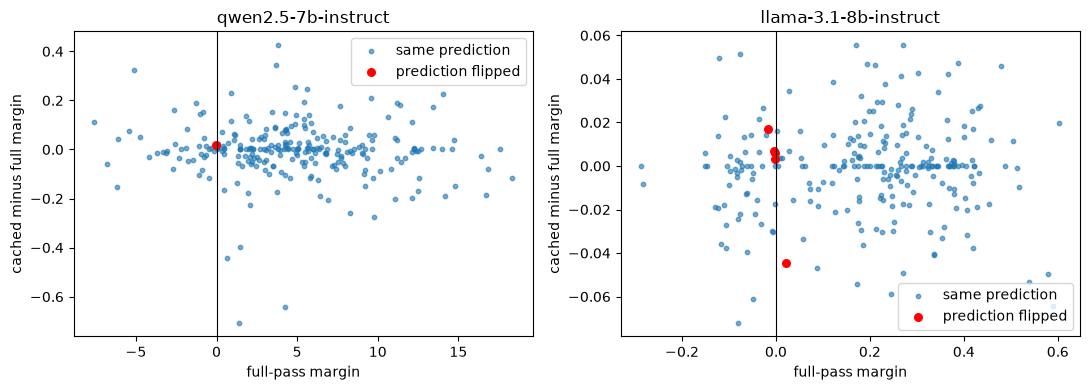

In [4]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(11, 4))
for ax, model in zip(axes, MODELS):
    s = pd.read_parquet(RESULTS / "p2" / f"benchmark_{model}_agreement.parquet")
    flip = s.prediction_cached != s.prediction_full
    d = s.margin_cached - s.margin_full
    ax.scatter(s.margin_full[~flip], d[~flip], s=10, alpha=0.6, label="same prediction")
    ax.scatter(s.margin_full[flip], d[flip], s=30, color="red", label="prediction flipped")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(model); ax.set_xlabel("full-pass margin"); ax.set_ylabel("cached minus full margin")
    ax.legend()
plt.tight_layout(); plt.show()

## 2. Learnability gate

The grid takes about an hour per model, so run it from a terminal (`scripts/run_p2.sh` runs the benchmarks, this grid and the gate):

```
caffeinate -i python scripts/run_synth_grid.py --run p2_learnability --suite pilot \
    --models qwen2.5-7b-instruct,llama-3.1-8b-instruct --envs id \
    --strategies zero_shot,label_diversity --label-modes gold,shuffled --k 8,16,32
python scripts/p2_learnability_gate.py
```

The demonstrations are label-balanced random sets: 4 of each class at k = 8.
The gold and shuffled conditions show the same rows in the same order; only the labels are permuted.

In [5]:
results = pd.read_parquet(RESULTS / "p2_learnability.parquet")
gate = learnability_gate(results)
print("smallest passing k:", smallest_passing_k(gate))
gate.round(3)

smallest passing k: {'llama-3.1-8b-instruct': None, 'qwen2.5-7b-instruct': 8}


,model,k,auroc_gold,auroc_shuffled,delta_auroc,ci_low,ci_high,tasks_positive,n_tasks,cal_ba_gold,cal_ba_shuffled,label_mass,auroc_zero_shot,label_mass_zero_shot,valid,passes
0,llama-3.1-8b-instruct,8,0.530,0.503,0.026,-0.021,0.074,8,12,0.503,0.493,0.023,0.535,0.0,False,False
1,llama-3.1-8b-instruct,16,0.538,0.496,0.042,-0.015,0.096,9,12,0.515,0.490,0.009,0.535,0.0,False,False
2,llama-3.1-8b-instruct,32,0.539,0.495,0.045,-0.018,0.104,10,12,0.506,0.503,0.109,0.535,0.0,False,False
3,qwen2.5-7b-instruct,8,0.592,0.494,0.098,0.021,0.188,9,12,0.510,0.494,0.996,0.499,1.0,True,True
4,qwen2.5-7b-instruct,16,0.613,0.454,0.159,0.074,0.238,11,12,0.546,0.492,0.996,0.499,1.0,True,True
5,qwen2.5-7b-instruct,32,0.585,0.499,0.086,-0.012,0.183,8,12,0.524,0.488,1.000,0.499,1.0,True,False


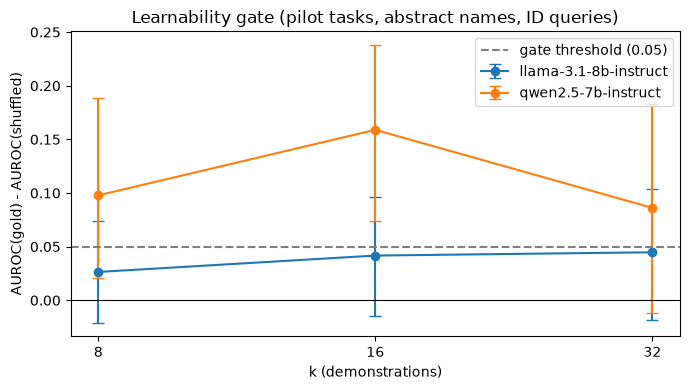

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for model, g in gate.groupby("model"):
    ax.errorbar(g["k"], g["delta_auroc"], yerr=[g["delta_auroc"] - g["ci_low"], g["ci_high"] - g["delta_auroc"]],
                marker="o", capsize=4, label=model)
ax.axhline(0.05, ls="--", color="grey", label="gate threshold (0.05)")
ax.axhline(0, color="black", lw=0.8)
ax.set_xscale("log", base=2); ax.set_xticks([8, 16, 32]); ax.set_xticklabels(["8", "16", "32"])
ax.set_xlabel("k (demonstrations)"); ax.set_ylabel("AUROC(gold) - AUROC(shuffled)")
ax.set_title("Learnability gate (pilot tasks, abstract names, ID queries)"); ax.legend()
plt.tight_layout(); plt.show()

The gate table's `label_mass` is the median probability on the label tokens, and `valid` requires at least 0.9.
Below: label bias and confidence (the share of queries predicted "1" before and after contextual calibration, and the median |margin|).

In [7]:
res = results[results.env == "id"].assign(margin=lambda d: d.logprob_1 - d.logprob_0)
(res.assign(raw_1=res.prediction == "1", cal_1=res.prediction_cal == "1", abs_margin=res.margin.abs())
    .groupby(["model", "strategy", "label_mode", "k"])
    .agg(raw_share_1=("raw_1", "mean"), cal_share_1=("cal_1", "mean"), median_abs_margin=("abs_margin", "median"))
    .round(2))

raw_share_1  cal_share_1  \
model                 strategy        label_mode k                              
llama-3.1-8b-instruct label_diversity gold       8          0.88         1.00   
                                                 16         0.82         0.47   
                                                 32         0.24         0.91   
                                      shuffled   8          0.89         0.97   
                                                 16         0.88         0.61   
                                                 32         0.23         0.91   
                      zero_shot       gold       0          1.00         0.00   
qwen2.5-7b-instruct   label_diversity gold       8          0.88         0.60   
                                                 16         0.84         0.38   
                                                 32         0.78         0.31   
                                      shuffled   8          0.87         0.64   
                                                 16         0.86         0.45   
                                                 32         0.73         0.28   
                      zero_shot       gold       0          0.53         0.00   

                                                     median_abs_margin  
model                 strategy        label_mode k                      
llama-3.1-8b-instruct label_diversity gold       8                0.21  
                                                 16               0.13  
                                                 32               0.11  
                                      shuffled   8                0.16  
                                                 16               0.14  
                                                 32               0.11  
                      zero_shot       gold       0                2.69  
qwen2.5-7b-instruct   label_diversity gold       8                4.68  
                                                 16               3.34  
                                                 32               1.71  
                                      shuffled   8                4.39  
                                                 16               2.81  
                                                 32               1.27  
                      zero_shot       gold       0                1.40

## 3. Answer format

`python scripts/p2_answer_format.py --model <model>` lists, for a few pilot prompts, the probability on the label tokens, the most likely next tokens and a short greedy reply.
Qwen answers with the label. Llama begins to explain its reasoning ("To infer the rule, …"), so its two-token scores carry almost no signal.
Starting the reply with `Label: ` fixed that on pilot prompts (label mass about 0.99), but Llama was paused instead (28 September).

In [8]:
rows = []
for model in MODELS:
    fmt = json.loads((RESULTS / "p2" / f"answer_format_{model}.json").read_text())
    for p in fmt["prompts"]:
        rows.append({"model": model, "condition": f"{p['strategy']}, k={p['k']}", "label mass": round(p["label_mass"], 4),
                     "top tokens": ", ".join(f"{t!r} {q:.2f}" for t, q in p["top_tokens"][:4]), "greedy reply": p["greedy"][:70]})
with pd.option_context("display.max_colwidth", 90):
    display(pd.DataFrame(rows).drop_duplicates(["model", "condition"]))

,model,condition,label mass,top tokens,greedy reply
0,qwen2.5-7b-instruct,"zero_shot, k=0",1.0000,"'1' 0.62, '0' 0.38, '１' 0.00, '�' 0.00",1
3,qwen2.5-7b-instruct,"label_diversity, k=8",1.0000,"'1' 1.00, '0' 0.00, '�' 0.00, '１' 0.00",1
6,llama-3.1-8b-instruct,"zero_shot, k=0",0.0000,"'To' 0.83, 'I' 0.05, 'There' 0.04, 'Since' 0.02","To infer the rule, I'll analyze the given examples. However, I need at"
9,llama-3.1-8b-instruct,"label_diversity, k=8",0.0251,"'To' 0.50, 'Based' 0.27, 'After' 0.11, 'From' 0.04","To infer the rule, I will analyze the given examples. \n\nAfter examinin"


## 4. Cost

Sustained cost per unit, from the grid itself (20 ID queries plus the content-free query), then P4-sized units (60 queries, 3 environments, `p2/p4_unit_timing.parquet`).
The compute budget in `docs/research_plan.md` is scaled from these figures.

In [9]:
units = results.drop_duplicates("unit_key")
display(units.groupby(["model", "k"])["unit_seconds"].agg(["count", "mean", "median", "max"]).round(1))
p4 = pd.read_parquet(RESULTS / "p2" / "p4_unit_timing.parquet").drop_duplicates("unit_key")
p4.groupby(["model", "k"])["unit_seconds"].agg(["count", "mean"]).round(1)

count  mean  median   max
model                 k                            
llama-3.1-8b-instruct 0      12   8.1     7.8  12.0
                      8      72  10.4     9.9  16.6
                      16     72  12.9    12.3  24.1
                      32     72  18.3    17.4  30.9
qwen2.5-7b-instruct   0      12   7.1     5.6  22.8
                      8      72   8.1     7.6  19.7
                      16     72  10.1     9.8  16.2
                      32     72  14.7    13.6  46.2

count  mean
model                 k              
llama-3.1-8b-instruct 8       2  23.6
                      16      2  25.2
                      32      2  30.5
qwen2.5-7b-instruct   8       2  24.1
                      16      2  25.6
                      32      2  32.2

## 5. Priors and naming (P3)

**What P3 asks:** does Qwen hold real-world beliefs about the feature names?
- If it does, flipped names set up a tug-of-war between the names and the demonstrations.
- Aligned names (e.g. *credit score* on a column where higher means approved) agree with the rule.
- Flipped names (*missed payments* on that column) contradict it.

**How:** Qwen answered 2,000 made-up rows with no demonstrations (`scripts/p3_prior_screen.py --stage screen`).
- Each row shows random values (z-scores) under names drawn from the candidate lexicon, in random columns.
- A ridge regression of Qwen's margin, log P("1") − log P("0"), on the named values gives each name a **slope**: positive means a bigger value pushes Qwen towards label 1.
- In the abstract condition the names are f0–f9.

In [10]:
import numpy as np
import yaml

from src.data.naming import load_lexicons

screen = json.loads((RESULTS / "p3" / "screen_qwen2.5-7b-instruct.json").read_text())
fits = screen["fits"]
display(pd.DataFrame({c: {"out-of-fold R2": f["r2_cv"], "intercept": f["intercept"], "profiles": f["n_profiles"],
                          "share predicted 1": f["share_predicted_1"], "label mass": f["label_mass_median"]}
                      for c, f in fits.items()}).T.round(3))
print("abstract slopes:", {k: round(v, 2) for k, v in fits["abstract"]["slopes"].items()})

,out-of-fold R2,intercept,profiles,share predicted 1,label mass
abstract,0.512,0.001,400.0,0.522,1.0
loan,0.202,-2.327,800.0,0.305,1.0
medical,0.278,1.405,800.0,0.689,1.0


abstract slopes: {'f0': 0.74, 'f1': 0.64, 'f2': 0.26, 'f3': 0.37, 'f4': 0.22, 'f5': 0.67, 'f6': 0.39, 'f7': 0.61, 'f8': 0.59, 'f9': 0.89}


Every abstract column has a positive slope: Qwen's zero-shot answer rises with every value.
This is the "bigger values mean 1" prior found in P2.
The named fits explain far less of Qwen's answers (R² 0.20 and 0.28; G3 asks for 0.5).

Below, each pair's two members are shown side by side.
The dashed line is the mean slope of the weak (administrative) names, i.e. the numeric prior on its own.

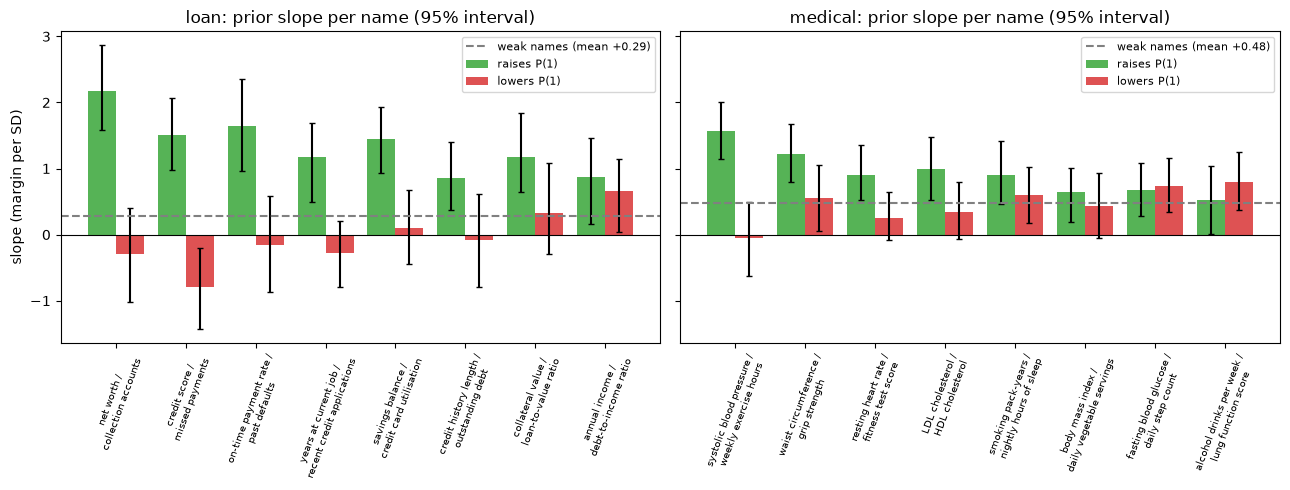

In [11]:
cand = load_lexicons("candidates")
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, dom in zip(axes, ["loan", "medical"]):
    f, sc = fits[dom], screen["screening"][dom]
    pairs = sorted(sc["pairs"], key=lambda p: -(p["slope_pos"] - p["slope_neg"]))
    x = np.arange(len(pairs))
    for off, key, colour, lab in ((-0.2, 0, "tab:green", "raises P(1)"), (0.2, 1, "tab:red", "lowers P(1)")):
        vals = [f["slopes"][p["pair"][key]] for p in pairs]
        err = np.array([[f["slopes"][p["pair"][key]] - f["slope_ci"][p["pair"][key]][0],
                         f["slope_ci"][p["pair"][key]][1] - f["slopes"][p["pair"][key]]] for p in pairs]).T
        ax.bar(x + off, vals, 0.4, yerr=err, color=colour, alpha=0.8, label=lab, capsize=2)
    weak_mean = np.mean([f["slopes"][w] for w in cand[dom].weak])
    ax.axhline(weak_mean, ls="--", color="grey", label=f"weak names (mean {weak_mean:+.2f})")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x, [f"{p['pair'][0]} /\n{p['pair'][1]}" for p in pairs], rotation=70, fontsize=7)
    ax.set_title(f"{dom}: prior slope per name (95% interval)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("slope (margin per SD)")
plt.tight_layout()

**What the chart shows:**
- Names that should raise P(1) have large slopes: *net worth*, *credit score*, *systolic blood pressure*.
- Names that should lower it mostly just push *less*, because the numeric prior lifts every slope. Only *missed payments* clearly reverses.
- In medical, protective names (*daily step count*, *HDL cholesterol*, *lung function score*) even push towards high risk.

The pre-registered screening rule needs b_p > 0 > b_q with matched strength. It admits 1 of 16 pairs, not the 3 per domain a task needs.

In [12]:
rows = []
for dom, sc in screen["screening"].items():
    for p in sc["pairs"]:
        rows.append({"domain": dom, "pair": " / ".join(p["pair"]), "b_p": p["slope_pos"], "b_q": p["slope_neg"],
                     "contrast": p["slope_pos"] - p["slope_neg"], "symmetry rule": p["admitted"]})
pairs_table = pd.DataFrame(rows).sort_values(["domain", "contrast"], ascending=[True, False])
final = load_lexicons("final")
pairs_table["final"] = [tuple(r.split(" / ")) in final[d].pairs for d, r in zip(pairs_table.domain, pairs_table.pair)]
display(pairs_table.round(2))
for dom, lex in final.items():
    print(f"{dom} weak names: {', '.join(lex.weak)}")

,domain,pair,b_p,b_q,contrast,symmetry rule,final
6,loan,net worth / collection accounts,2.17,-0.30,2.47,False,True
0,loan,credit score / missed payments,1.50,-0.79,2.29,True,True
4,loan,on-time payment rate / past defaults,1.64,-0.15,1.79,False,True
3,loan,years at current job / recent credit applications,1.17,-0.28,1.45,False,True
2,loan,savings balance / credit card utilisation,1.44,0.10,1.34,False,True
5,loan,credit history length / outstanding debt,0.86,-0.08,0.94,False,False
7,loan,collateral value / loan-to-value ratio,1.18,0.32,0.86,False,False
1,loan,annual income / debt-to-income ratio,0.87,0.67,0.20,False,False
8,medical,systolic blood pressure / weekly exercise hours,1.57,-0.05,1.62,False,True
15,medical,waist circumference / grip strength,1.22,0.55,0.67,False,True


loan weak names: form version, mailing batch number, office floor number, loan officer ID, days since form printed, applicant ID last digit, hour of submission
medical weak names: printer tray number, staff ID digit, clinic room number, form page count, chart version, waiting room seat number, minutes since check-in


### G3: do the names shift Qwen's prior on real tasks?

The final names are the 5 pairs per domain with the largest contrast b_p − b_q, plus the 7 weakest weak names.
They were tested zero-shot on the 12 pilot tasks' ID queries under each naming:

```
python scripts/run_synth_grid.py --run p3/zero_shot_pilot_provisional --suite pilot \
    --models qwen2.5-7b-instruct --namings abstract,aligned,flipped --strategies zero_shot --envs id \
    --lexicon-stage provisional
```

The run used the block then called "provisional", which is identical to the final names; `scripts/p3_naming_gate.py` writes `p3/naming_gate.json`.
G3 uses AUROC rather than raw accuracy, because zero-shot predictions are not calibrated.

In [13]:
from src.evaluation.metrics import auroc

gate = json.loads((RESULTS / "p3" / "naming_gate.json").read_text())["models"]["qwen2.5-7b-instruct"]
print(f"surrogate R2: {gate['r2_by_domain']}  (pre-registered criterion met: {gate['passes_r2']})")
print(f"zero-shot AUROC aligned - flipped: {gate['delta_auroc']:+.3f} [{gate['ci_low']:+.3f}, {gate['ci_high']:+.3f}], "
      f"{gate['tasks_positive']}/{gate['n_tasks']} tasks; raw accuracy {gate['delta_accuracy']:+.3f}")
zs = pd.read_parquet(RESULTS / "p3" / "zero_shot_pilot_provisional.parquet")
per_task = (zs.groupby(["task_id", "domain", "family", "naming"])
              .apply(lambda c: auroc(c["label"].astype(int), c["p1"]), include_groups=False)
              .unstack("naming"))
per_task["aligned - flipped"] = per_task["aligned"] - per_task["flipped"]
display(per_task.round(2))
display(per_task.groupby(level="domain").mean().round(3))

surrogate R2: {'loan': 0.20239694255816454, 'medical': 0.2779124549962756}  (pre-registered criterion met: False)
zero-shot AUROC aligned - flipped: +0.164 [+0.053, +0.287], 10/12 tasks; raw accuracy +0.113


,,naming,abstract,aligned,flipped,aligned - flipped
task_id,domain,family,,,,
pilot_0000,loan,linear,0.89,0.84,0.62,0.22
pilot_0001,medical,linear,0.31,0.56,0.55,0.01
pilot_0002,loan,linear,0.35,0.60,0.12,0.48
pilot_0003,medical,linear,0.71,0.50,0.52,-0.02
pilot_0004,loan,linear,0.65,0.81,0.38,0.43
pilot_0005,medical,linear,0.36,0.43,0.38,0.05
pilot_0006,loan,tree,0.36,0.49,0.21,0.28
pilot_0007,medical,tree,0.41,0.41,0.35,0.06
pilot_0008,loan,tree,0.67,0.68,0.69,-0.01


naming,abstract,aligned,flipped,aligned - flipped
domain,,,,
loan,0.508,0.688,0.41,0.278
medical,0.490,0.500,0.45,0.050


**G3 outcome:**
- The surrogate's fit fails the pre-registered criterion.
- The manipulation works: flipping the three rule-feature names lowers Qwen's zero-shot AUROC from 0.59 to 0.43, with a 95% interval above 0 on 10 of 12 tasks.
- The effect is strong in loan (0.69 → 0.41) and weak in medical (0.50 → 0.45).

**The user's decision (30 September 2026):** keep the naming factor.
- counter_prior no longer uses the surrogate. It uses Qwen's own zero-shot answer on each of a task's 256 pool rows (`scripts/p3_pool_priors.py`), with the margin centred on the pool median to remove the label bias.
- It then picks demonstrations whose label contradicts that answer and follows the rule.
- The surrogate stays as a description of the name priors.

### Measured priors and the prior–data conflict

C_t is the share of a task's pool rows whose label Qwen's centred zero-shot answer gets wrong.
It should be below 1/2 under aligned names and above 1/2 under flipped names.
counter_prior is active only where C_t > 1/2, and otherwise shows label_diversity's set.
This cell fills in once P4 has measured the pool priors.

In [14]:
path = RESULTS / "p3" / "pool_prior_qwen2.5-7b-instruct.parquet"
if path.exists():
    pp = pd.read_parquet(path)
    rows = []
    for (task, naming), g in pp.groupby(["task_id", "naming"]):
        m = (g["logprob_1"] - g["logprob_0"]).to_numpy()
        rows.append({"task_id": task, "naming": naming,
                     "C_t": float(np.mean(((m - np.median(m)) > 0) != (g["label"].to_numpy() == 1))),
                     "AUROC of the prior": auroc(g["label"].to_numpy(), m)})
    conflict = pd.DataFrame(rows).pivot_table(index="task_id", columns="naming", values=["C_t", "AUROC of the prior"])
    display(conflict.round(2))
    display(conflict.mean().unstack(0).round(3))
else:
    print("pool priors not measured yet (P4 stage `abstract` / `named_priors`)")

pool priors not measured yet (P4 stage `abstract` / `named_priors`)
